# Part - III: Language Tasks
## (Sentiment Analysis) Text Classification with RNN
### SMS Spam Detection using RNN, LSTM, and Word2Vec Embeddings

**Course:** 6CS012 — Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu | University of Wolverhampton  
**Dataset:** Spam vs Ham SMS Dataset  

---

## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

### Step 1: Import Required Libraries

Mount Google Drive

In [115]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [116]:
zip_path = '/content/drive/MyDrive/Assessment_Dataset/Spam vs Ham Sms Dataset.zip'

Extract Dataset from ZIP

In [117]:
import zipfile
import os

extract_path = '/content/Spam vs Ham Sms_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

# List contents of the extracted directory to verify structure
!ls -R "{extract_path}"

Extracted to: /content/Spam vs Ham Sms_dataset
'/content/Spam vs Ham Sms_dataset':
'9.Spam vs Ham Sms Dataset'

'/content/Spam vs Ham Sms_dataset/9.Spam vs Ham Sms Dataset':
'9.Description Spam Vs. Ham Dataset.txt'   spamvsham.csv


Import Required Libraries

In [118]:
# Install required packages (run once if not already installed)
# !pip install nltk wordcloud contractions
# !pip install numpy==1.23.5 gensim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# WordCloud
from wordcloud import WordCloud

# Fix random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.20.0


Load Dataset using Pandas

In [119]:
file_path = '/content/Spam vs Ham Sms_dataset/9.Spam vs Ham Sms Dataset/spamvsham.csv'

df = pd.read_csv(
    file_path,
    encoding='latin-1',        # Handles special characters
    usecols=[0, 1],            # Select only label and text columns
    names=['label', 'text'],   # Rename columns for clarity
    header=0
)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

# Display first 5 rows
df.head()

Dataset loaded successfully!
Shape of dataset: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Basic Dataset Analysis

In [120]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Total samples       : {len(df)}")
print(f"Number of features  : {df.shape[1]}")
print(f"Missing values      : {df.isnull().sum().sum()}")

print("\nClass Distribution:")
print(df['label'].value_counts())

# Percentage distribution
spam_pct = df['label'].value_counts(normalize=True)['spam'] * 100
ham_pct = df['label'].value_counts(normalize=True)['ham'] * 100

print(f"\nSpam percentage : {spam_pct:.2f}%")
print(f"Ham percentage  : {ham_pct:.2f}%")

DATASET OVERVIEW
Total samples       : 5572
Number of features  : 2
Missing values      : 0

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage : 13.41%
Ham percentage  : 86.59%


Visualization

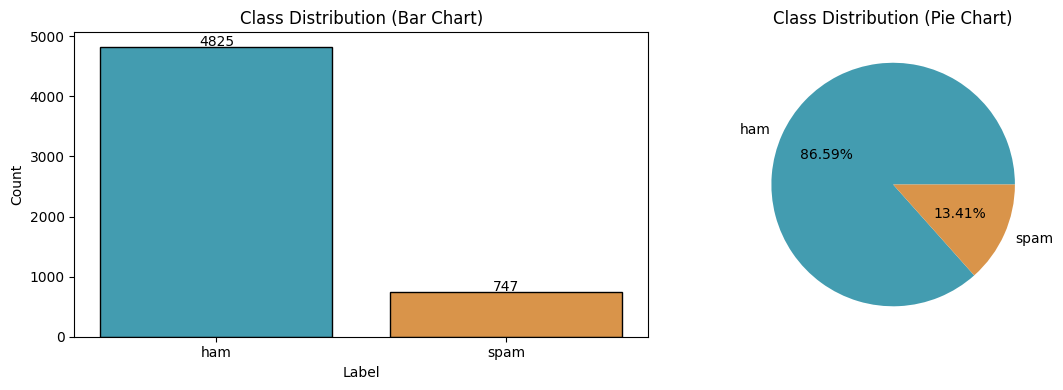

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Force correct order
counts = df['label'].value_counts().reindex(['ham', 'spam'])

# Softer academic colors
colors = ['#439cb0', '#d9944a']  # ham, spam

# ======================
# Bar Chart
# ======================
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center')

# ======================
# Pie Chart
# ======================
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct='%1.2f%%',
    colors=colors
)
axes[1].set_title('Class Distribution (Pie Chart)')

plt.tight_layout()

# ✅ SAVE IMAGE AS PNG
plt.savefig("class_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Step 3: Text Cleaning and Preprocessing

The following preprocessing pipeline is applied:
1. **Lowercase** — Ensures uniformity across all tokens.
2. **Remove URLs, mentions, hashtags, numbers, and special characters** — Removes noise irrelevant to meaning.
3. **Handle contractions** — Expands shortened forms (e.g., `don't` → `do not`) to preserve semantic meaning.
4. **Remove stopwords** — Eliminates high-frequency, low-information words (e.g., *the*, *is*).
5. **Lemmatization** — Reduces words to their root form (e.g., *running* → *run*), reducing vocabulary size.

In [122]:
# ==============================
# STEP 1: Setup
# ==============================
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ==============================
# STEP 2: Contraction Dictionary
# ==============================
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "don't": "do not",
    "doesn't": "does not", "didn't": "did not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "hasn't": "has not", "haven't": "have not", "hadn't": "had not",
    "wouldn't": "would not", "shouldn't": "should not", "couldn't": "could not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "they're": "they are",
    "n't": " not", "'re": " are", "'ve": " have", "'ll": " will", "'d": " would", "'m": " am"
}

def expand_contractions(text):
    pattern = re.compile('({})'.format('|'.join(CONTRACTIONS.keys())), flags=re.IGNORECASE)
    return pattern.sub(lambda x: CONTRACTIONS.get(x.group(0).lower(), x.group(0)), text)

# ==============================
# STEP 3: Text Cleaning Function
# ==============================
def clean_text(text):
    """
    Complete preprocessing pipeline:
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions (before removing symbols)
    text = expand_contractions(text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 4. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # 5. Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenization + Stopword removal + Lemmatization
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(tokens)

# ==============================
# STEP 4: Apply Cleaning
# ==============================
df['clean_text'] = df['text'].apply(clean_text)

# Encode labels
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

print("Text preprocessing completed successfully.")

# ==============================
# STEP 5: Sample Output
# ==============================
print("\nSample — Original vs Cleaned:")
for i in [0, 2, 5]:
    print(f"\n[{df['label'].iloc[i].upper()}]")
    print("Original :", df['text'].iloc[i][:100])
    print("Cleaned  :", df['clean_text'].iloc[i][:100])

Text preprocessing completed successfully.

Sample — Original vs Cleaned:

[HAM]
Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a
Cleaned  : go jurong point crazy available bugis great world la buffet cine got amore wat

[SPAM]
Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr
Cleaned  : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate apply

[SPAM]
Original : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it s
Cleaned  : freemsg hey darling week word back would like fun still tb ok xxx std chgs send rcv


### Step 4: Visualize Cleaned Data

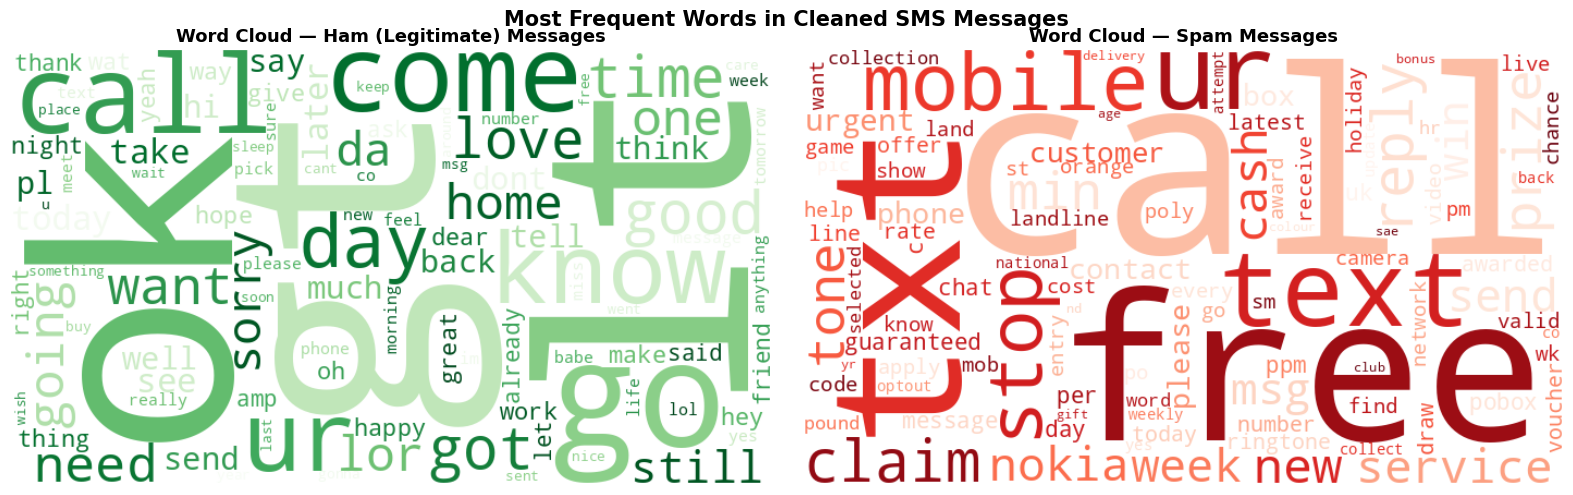

Observation:
- Spam messages contain promotional words such as 'free', 'win', 'offer'.
- Ham messages contain more conversational and personal words.
- Cleaning reduces noise and highlights meaningful tokens.


In [123]:
# ==============================
# WORD CLOUD VISUALIZATION
# ==============================

from wordcloud import WordCloud

assert 'clean_text' in df.columns, "Column 'clean_text' not found!"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = ['ham', 'spam']
colormaps = ['Greens', 'Reds']
titles = ['Ham (Legitimate) Messages', 'Spam Messages']

for ax, label, cmap, title in zip(axes, labels, colormaps, titles):

    corpus = ' '.join(df[df['label'] == label]['clean_text'].dropna())

    if len(corpus.strip()) == 0:
        print(f"No data available for {label}")
        continue

    wc = WordCloud(
        width=700,
        height=400,
        background_color='white',
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate(corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {title}', fontsize=13, fontweight='bold')

plt.suptitle('Most Frequent Words in Cleaned SMS Messages', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("wordcloud_cleaned_sms.png", dpi=300, bbox_inches='tight')
plt.show()

# ✅ ADD OBSERVATION HERE
print("Observation:")
print("- Spam messages contain promotional words such as 'free', 'win', 'offer'.")
print("- Ham messages contain more conversational and personal words.")
print("- Cleaning reduces noise and highlights meaningful tokens.")

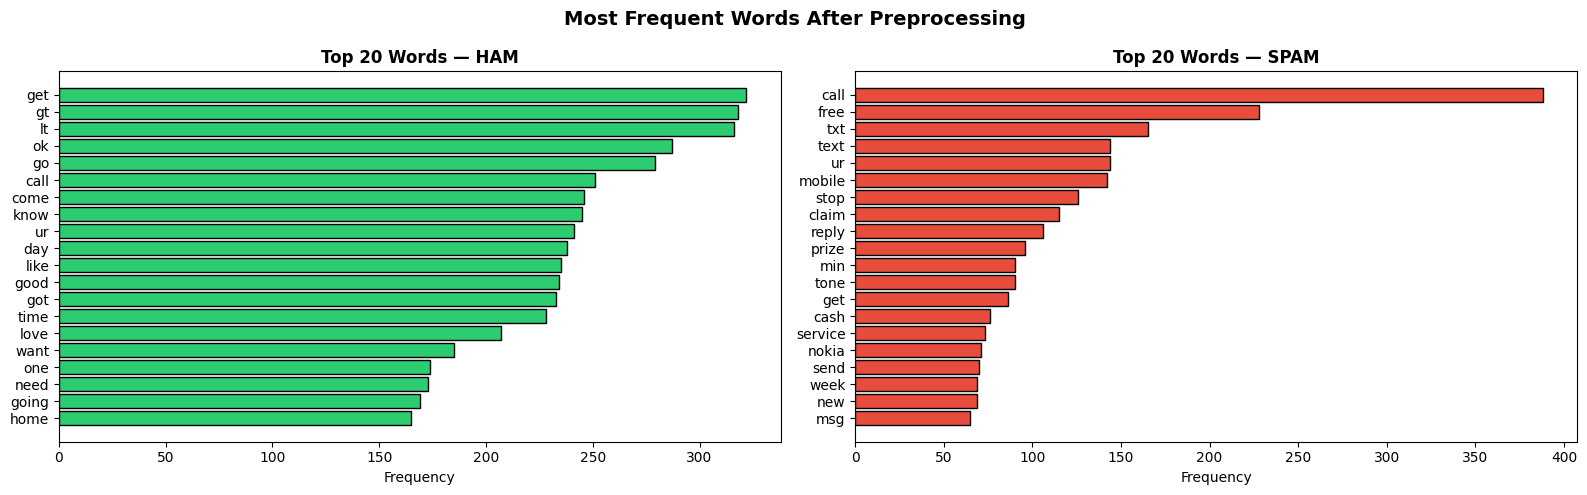

In [126]:
# ==============================
# TOP FREQUENT WORDS ANALYSIS
# ==============================

from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {'ham': '#2ecc71', 'spam': '#e74c3c'}

for ax, label in zip(axes, ['ham', 'spam']):

    words = ' '.join(df[df['label'] == label]['clean_text']).split()

    # Count most common words
    common_words = Counter(words).most_common(20)

    words_list, counts = zip(*common_words)

    ax.barh(words_list[::-1], counts[::-1], color=colors[label], edgecolor='black')
    ax.set_title(f'Top 20 Words — {label.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Message Length Analysis

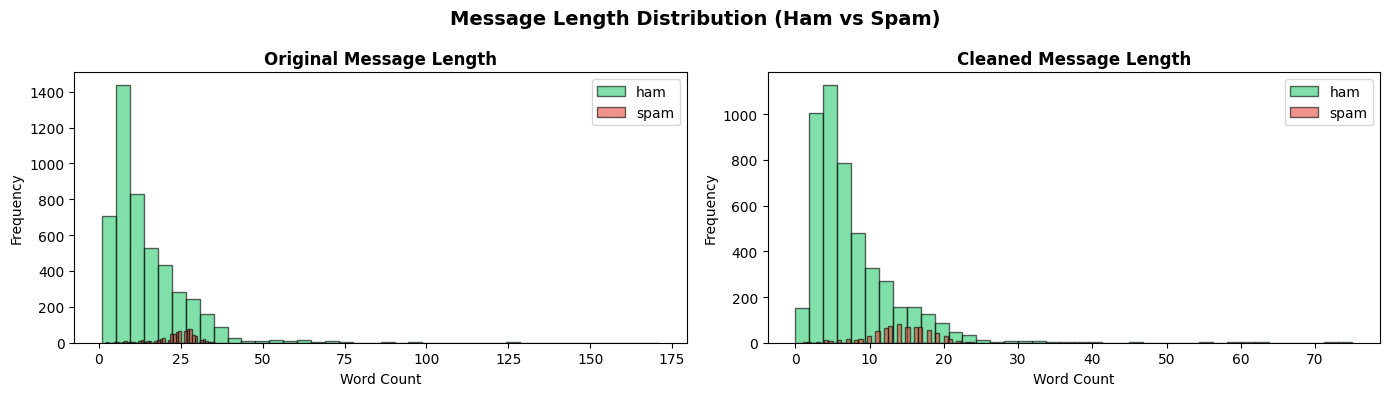


Message Length Statistics:
      text_len                                             clean_len         \
         count   mean    std  min   25%   50%   75%    max     count   mean   
label                                                                         
ham     4825.0  14.20  11.42  1.0   7.0  11.0  19.0  171.0    4825.0   7.57   
spam     747.0  23.85   5.81  2.0  22.0  25.0  28.0   35.0     747.0  14.12   

                                          
        std  min   25%   50%   75%   max  
label                                     
ham    6.07  0.0   4.0   6.0  10.0  75.0  
spam   4.09  1.0  12.0  14.0  17.0  24.0  


In [127]:
# ==============================
# MESSAGE LENGTH ANALYSIS
# ==============================

# Create length features
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
df['clean_len'] = df['clean_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

columns = ['text_len', 'clean_len']
titles = ['Original Message Length', 'Cleaned Message Length']

for ax, col, title in zip(axes, columns, titles):

    for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
        subset = df[df['label'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='black')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Message Length Distribution (Ham vs Spam)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("message_length_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Statistical Summary
print("\nMessage Length Statistics:")
print(df.groupby('label')[['text_len', 'clean_len']].describe().round(2))

### Step 5: Tokenization and Sequence Padding

The dataset is split into **80% training** and **20% testing**. Keras `Tokenizer` converts text into integer sequences. **Percentile-based padding** is applied to avoid inflating the sequence length with extreme outliers.

In [128]:
# ==============================
# STEP 1: Train-Test Split (80/20)
# ==============================
from sklearn.model_selection import train_test_split

X = df['clean_text'].values
y = df['label_enc'].values

# Stratified split ensures class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed:")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Train spam count : {y_train.sum()} | Train ham count : {(y_train==0).sum()}")
print(f"Test  spam count : {y_test.sum()} | Test  ham count : {(y_test==0).sum()}")

Train-Test Split Completed:
Training samples : 4457
Testing samples  : 1115
Train spam count : 598 | Train ham count : 3859
Test  spam count : 149 | Test  ham count : 966


In [129]:
# ==============================
# STEP 2: Tokenization
# ==============================
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 10000   # Limit vocabulary size to most frequent words
OOV_TOKEN = '<OOV>' # Handle unseen words

# Initialize tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)

# Fit ONLY on training data to prevent data leakage
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index)) + 1

print("\nTokenization Completed:")
print(f"Total unique words (training set): {len(word_index)}")
print(f"Vocabulary size used in model    : {vocab_size}")


Tokenization Completed:
Total unique words (training set): 6224
Vocabulary size used in model    : 6225


In [130]:
# ==============================
# STEP 3: Convert Text to Sequences
# ==============================
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print("\nExample sequence:")
print(X_train_seq[0])


Example sequence:
[22, 225, 56, 1034]


In [131]:
# ==============================
# STEP 4: Sequence Length Analysis
# ==============================
import numpy as np
import matplotlib.pyplot as plt

# Compute sequence lengths
seq_lengths = [len(seq) for seq in X_train_seq]

# Use 95th percentile to avoid very long outliers
MAX_LEN = int(np.percentile(seq_lengths, 95))

print("\nSequence Length Statistics:")
print(f"Min length   : {min(seq_lengths)}")
print(f"Max length   : {max(seq_lengths)}")
print(f"Mean length  : {np.mean(seq_lengths):.2f}")
print(f"Median       : {np.median(seq_lengths)}")
print(f"Chosen MAX_LEN (95th percentile): {MAX_LEN}")


Sequence Length Statistics:
Min length   : 0
Max length   : 75
Mean length  : 8.42
Median       : 7.0
Chosen MAX_LEN (95th percentile): 19


In [132]:
# ==============================
# STEP 5: Padding Sequences
# ==============================
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad sequences to ensure equal length input for neural networks
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("\nPadding Completed:")
print(f"X_train shape: {X_train_pad.shape}")
print(f"X_test shape : {X_test_pad.shape}")

print("\nSample padded sequence:")
print(X_train_pad[0])


Padding Completed:
X_train shape: (4457, 19)
X_test shape : (1115, 19)

Sample padded sequence:
[  22  225   56 1034    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0]


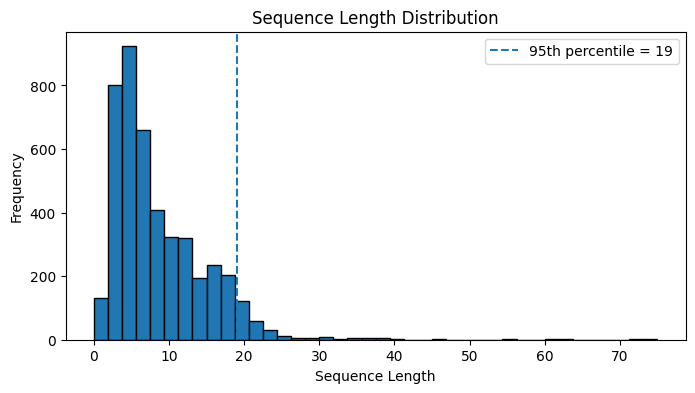

In [133]:
# ==============================
# STEP 6: Visualization
# ==============================

plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=40, edgecolor='black')
plt.axvline(MAX_LEN, linestyle='--', label=f'95th percentile = {MAX_LEN}')

plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.legend()

# Save figure as PNG
plt.savefig("sequence_length_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

---
## 4.5.2 Model Building and Training

Three models are built for binary text classification (spam vs ham):
1. **Model 1** — Simple RNN with a trainable Embedding layer
2. **Model 2** — LSTM with a trainable Embedding layer
3. **Model 3** — LSTM with pretrained GloVe (Word2Vec-style) embeddings

In [134]:
# ==============================
# SHARED HYPERPARAMETERS
# ==============================
EMBEDDING_DIM = 64   # Dimension of word embeddings
BATCH_SIZE    = 32   # Number of samples per batch
EPOCHS        = 20   # Maximum epochs (early stopping applied)

# Early Stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Display configuration (for reproducibility)
print("Model Configuration:")
print(f"Vocabulary Size      : {vocab_size}")
print(f"Max Sequence Length  : {MAX_LEN}")
print(f"Embedding Dimension  : {EMBEDDING_DIM}")
print(f"Batch Size           : {BATCH_SIZE}")
print(f"Epochs (max)         : {EPOCHS}")

Model Configuration:
Vocabulary Size      : 6225
Max Sequence Length  : 19
Embedding Dimension  : 64
Batch Size           : 32
Epochs (max)         : 20


### Model 1: Simple RNN with Trainable Embedding

In [135]:
# ==============================
# MODEL 1: SIMPLE RNN
# ==============================
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# IMPORTANT: Build model before summary
rnn_model.build(input_shape=(None, MAX_LEN))

print("Model 1 Summary:")
rnn_model.summary()

Model 1 Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 19, 64)         │       398,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408,769 (1.56 MB)

 Trainable params: 408,769 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

In [136]:
# Train Model 1
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.8993 - loss: 0.2976 - val_accuracy: 0.9439 - val_loss: 0.2177
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9516 - loss: 0.1818 - val_accuracy: 0.9552 - val_loss: 0.1985
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9681 - loss: 0.1276 - val_accuracy: 0.9641 - val_loss: 0.1625
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9803 - loss: 0.0883 - val_accuracy: 0.9686 - val_loss: 0.1399
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9850 - loss: 0.0727 - val_accuracy: 0.9664 - val_loss: 0.1745
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9828 - loss: 0.0771 - val_accuracy: 0.9686 - val_loss: 0.1721
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9883 - loss: 0.0601 - val_accuracy: 0.9596 - val_loss: 0.1737
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


### Model 2: LSTM with Trainable Embedding

In [137]:
# ==============================
# MODEL 2: LSTM
# ==============================
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, MAX_LEN))

print("Model 2 Summary:")
lstm_model.summary()

Model 2 Summary:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 19, 64)         │       398,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,537 (1.65 MB)

 Trainable params: 433,537 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [138]:
# Train Model 2
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9237 - loss: 0.2259 - val_accuracy: 0.9686 - val_loss: 0.1006
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9860 - loss: 0.0565 - val_accuracy: 0.9664 - val_loss: 0.0950
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9945 - loss: 0.0268 - val_accuracy: 0.9753 - val_loss: 0.0775
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9955 - loss: 0.0157 - val_accuracy: 0.9753 - val_loss: 0.1020
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9978 - loss: 0.0094 - val_accuracy: 0.9753 - val_loss: 0.1212
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9985 - loss: 0.0046 - val_accuracy: 0.9776 - val_loss: 0.1268
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


### Model 3: LSTM with Pretrained Word2Vec / GloVe Embeddings

Pretrained GloVe embeddings (`glove-wiki-gigaword-50`) are used to initialise the Embedding layer. These embeddings encode semantic relationships learned from billions of words, providing a richer representation than randomly initialised weights.

In [139]:
# ==============================
# STEP 1: Load Pretrained Word2Vec
# ==============================
!pip install gensim --quiet

import gensim.downloader as api

print("Loading pretrained Word2Vec (Google News 300)...")
word2vec_model = api.load('word2vec-google-news-300')
W2V_DIM = 300
print("Word2Vec loaded successfully.")

Loading pretrained Word2Vec (Google News 300)...
Word2Vec loaded successfully.


In [140]:
# ==============================
# STEP 2: Build Embedding Matrix
# ==============================
embedding_matrix = np.zeros((vocab_size, W2V_DIM))

hits, misses = 0, 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]
        hits += 1
    else:
        misses += 1  # words not found → remain zero

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Coverage              : {hits/(hits+misses)*100:.2f}% words found")

Embedding matrix shape : (6225, 300)
Coverage              : 80.59% words found


In [141]:
# ==============================
# STEP 3: Build LSTM Model
# ==============================
lstm_w2v_model = Sequential(name="LSTM_Word2Vec_Model")

lstm_w2v_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=W2V_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False   # freeze pretrained embeddings
))

lstm_w2v_model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
lstm_w2v_model.add(Dense(32, activation='relu'))
lstm_w2v_model.add(Dropout(0.3))
lstm_w2v_model.add(Dense(1, activation='sigmoid'))

lstm_w2v_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Build model explicitly (important for summary clarity)
lstm_w2v_model.build(input_shape=(None, MAX_LEN))

print("Model 3 (Word2Vec) Summary:")
lstm_w2v_model.summary()

Model 3 (Word2Vec) Summary:


Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 19, 300)        │     1,867,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,963,053 (7.49 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 1,867,500 (7.12 MB)

In [142]:
# ==============================
# STEP 4: Train Model
# ==============================
print("Training Model 3 (Word2Vec)...")

history_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Training Model 3 (Word2Vec)...
Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9354 - loss: 0.2125 - val_accuracy: 0.9507 - val_loss: 0.1225
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9713 - loss: 0.0849 - val_accuracy: 0.9596 - val_loss: 0.0998
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9768 - loss: 0.0720 - val_accuracy: 0.9686 - val_loss: 0.0748
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9793 - loss: 0.0667 - val_accuracy: 0.9686 - val_loss: 0.0799
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9840 - loss: 0.0536 - val_accuracy: 0.9798 - val_loss: 0.0679
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9853 - loss: 0.0518 - val_accuracy: 0.9641 - val_loss: 0.0829
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9853 - loss: 0.0476 - val_accuracy: 0.9686 - val_loss: 0.0848
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 

---
## 4.5.3 Model Training and Evaluation

### Visualization: Training vs Validation Loss and Accuracy

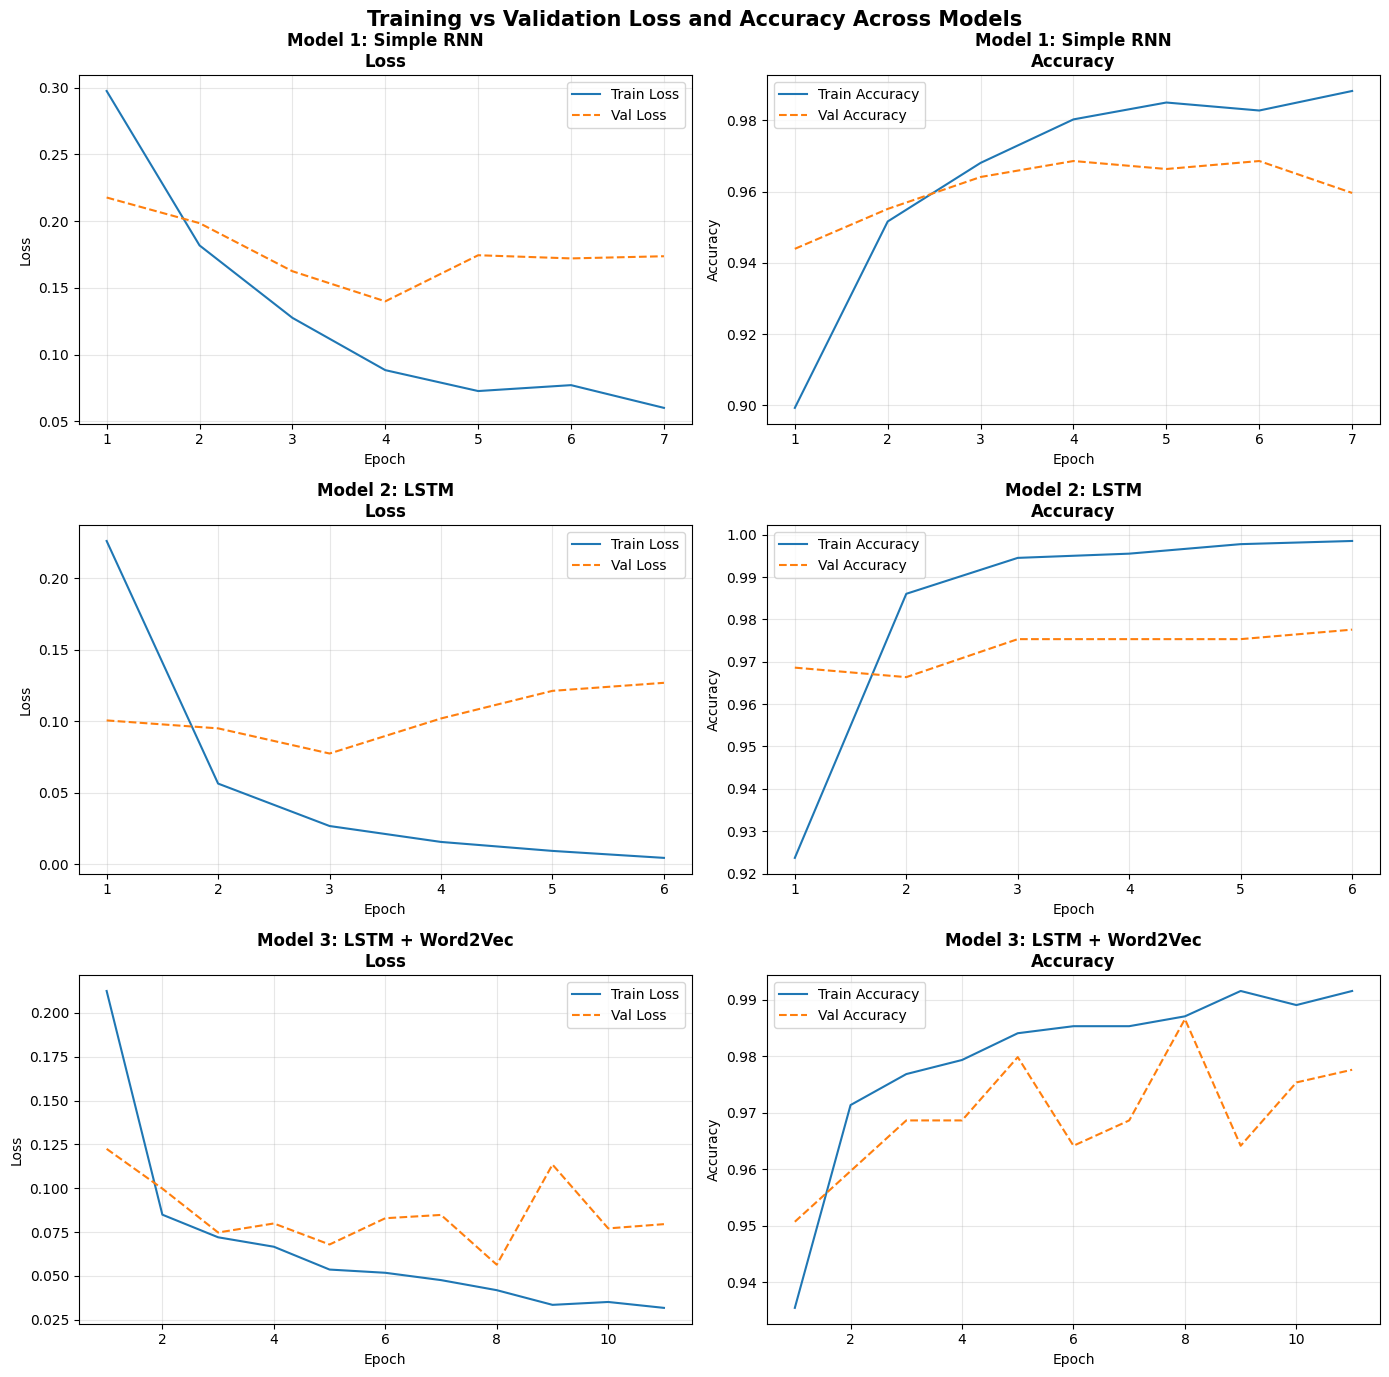

In [143]:
def plot_history(history, model_name, ax_loss, ax_acc):
    """Plot training and validation loss and accuracy curves."""
    epochs_ran = range(1, len(history.history['loss']) + 1)

    # Loss
    ax_loss.plot(epochs_ran, history.history['loss'], label='Train Loss')
    ax_loss.plot(epochs_ran, history.history['val_loss'], linestyle='--', label='Val Loss')
    ax_loss.set_title(f'{model_name}\nLoss', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    # Accuracy
    ax_acc.plot(epochs_ran, history.history['accuracy'], label='Train Accuracy')
    ax_acc.plot(epochs_ran, history.history['val_accuracy'], linestyle='--', label='Val Accuracy')
    ax_acc.set_title(f'{model_name}\nAccuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)


fig, axes = plt.subplots(3, 2, figsize=(14, 14))

plot_history(history_rnn,  'Model 1: Simple RNN', axes[0, 0], axes[0, 1])
plot_history(history_lstm, 'Model 2: LSTM',       axes[1, 0], axes[1, 1])
plot_history(history_w2v,  'Model 3: LSTM + Word2Vec', axes[2, 0], axes[2, 1])

plt.suptitle('Training vs Validation Loss and Accuracy Across Models',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig("training_validation_curves.png", dpi=300, bbox_inches='tight')
plt.show()

Evaluation Function

In [144]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")

    # Evaluate (IMPORTANT)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss     : {loss:.4f}")
    print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")

    # Predictions
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    return y_pred, acc

Evaluate All Models

In [145]:
y_pred_rnn, acc_rnn   = evaluate_model(rnn_model, X_test_pad, y_test, "Model 1: Simple RNN")
y_pred_lstm, acc_lstm = evaluate_model(lstm_model, X_test_pad, y_test, "Model 2: LSTM")
y_pred_w2v, acc_w2v   = evaluate_model(lstm_w2v_model, X_test_pad, y_test, "Model 3: LSTM + Word2Vec")


Model 1: Simple RNN
Test Loss     : 0.1214
Test Accuracy : 0.9740 (97.40%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.94      0.86      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115


Model 2: LSTM
Test Loss     : 0.0667
Test Accuracy : 0.9821 (98.21%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Model 3: LSTM + Word2Vec
Test Loss     : 0.0681
Test Accuracy : 0.9803 (98.03%)

Classification Report:
              precision    recall  f1-score   s

Confusion Matrices

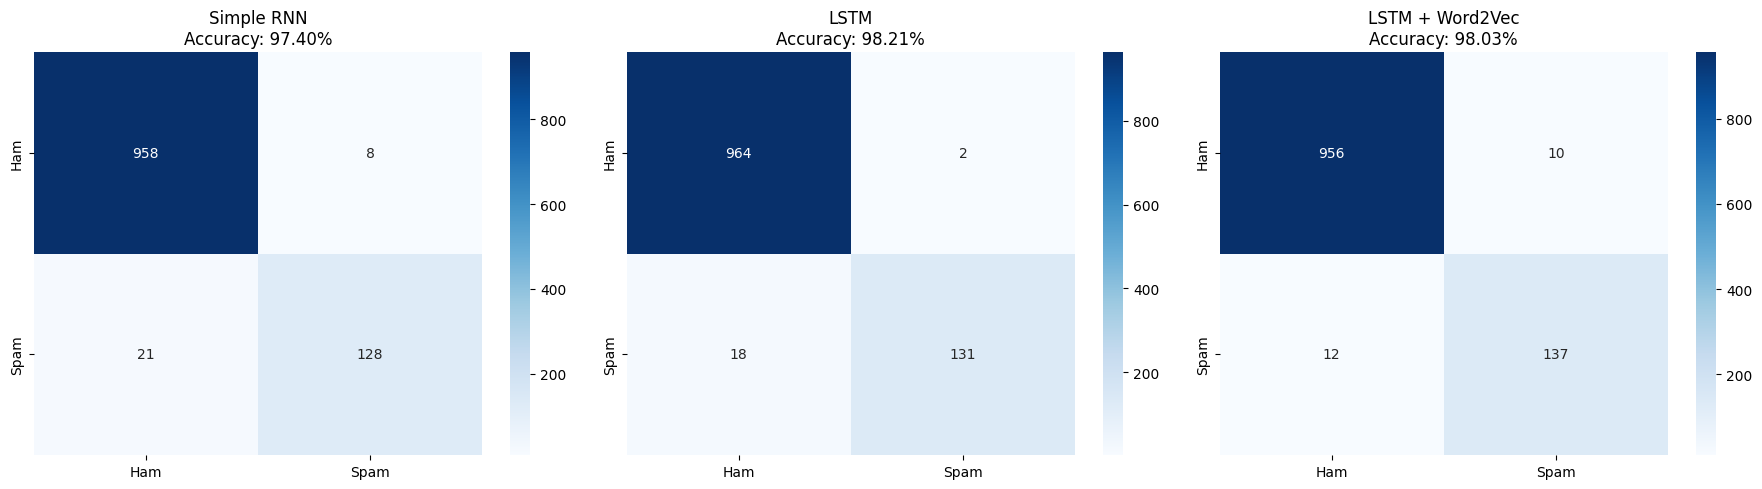

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Simple RNN", y_pred_rnn, acc_rnn),
    ("LSTM", y_pred_lstm, acc_lstm),
    ("LSTM + Word2Vec", y_pred_w2v, acc_w2v)
]

for ax, (name, preds, acc) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(f"{name}\nAccuracy: {acc*100:.2f}%")

plt.tight_layout()

# ✅ Save as PNG image
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches='tight')

plt.show()

Model Comparison (Cleaner)

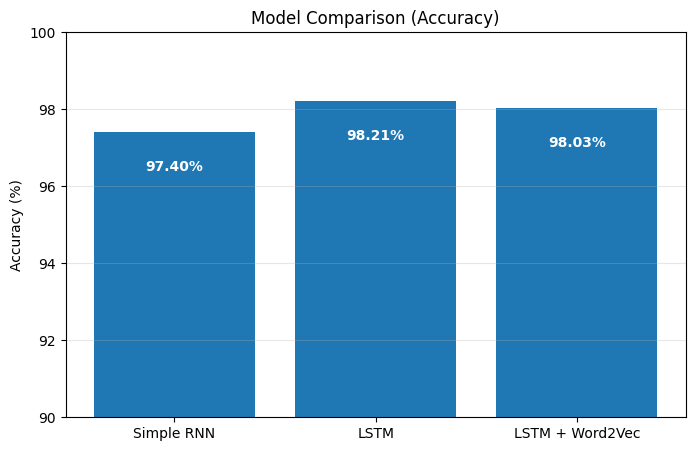


Model Performance Summary:
             Model  Accuracy (%)
0       Simple RNN     97.399104
1             LSTM     98.206276
2  LSTM + Word2Vec     98.026907


In [147]:
# ==============================
# Model Comparison (Best Version)
# ==============================

model_names = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
accuracies = [acc_rnn*100, acc_lstm*100, acc_w2v*100]

# 📊 Bar Chart (visual clarity)
plt.figure(figsize=(8,5))
bars = plt.bar(model_names, accuracies)

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1,
             f'{val:.2f}%', ha='center', color='white', fontweight='bold')

plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 100)
plt.grid(axis='y', alpha=0.3)

# ✅ SAVE IMAGE AS PNG (IMPORTANT)
plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches='tight')

plt.show()


# 📋 Table (academic strength)
comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy (%)": accuracies
})

print("\nModel Performance Summary:")
print(comparison_df)

4.5.4 Error Analysis

Misclassified Examples

Misclassified instances are extracted from the LSTM model predictions to understand failure cases and improve model robustness.

1. Identification of Misclassified Samples (LSTM Model)

In [148]:
# ==============================
# MISCLASSIFIED EXAMPLES
# ==============================

# Calculate y_prob_lstm to resolve NameError
y_prob_lstm = lstm_model.predict(X_test_pad, verbose=0).flatten()

test_df = pd.DataFrame({
    'text': X_test,
    'true_label': ['spam' if l == 1 else 'ham' for l in y_test],
    'pred_label': ['spam' if p == 1 else 'ham' for p in y_pred_lstm],
    'confidence': y_prob_lstm
})

misclassified = test_df[test_df['true_label'] != test_df['pred_label']].reset_index(drop=True)

print("Total Misclassified Samples:", len(misclassified))
print("False Positives (Ham → Spam):", len(misclassified[misclassified['true_label'] == 'ham']))
print("False Negatives (Spam → Ham):", len(misclassified[misclassified['true_label'] == 'spam']))

Total Misclassified Samples: 20
False Positives (Ham → Spam): 2
False Negatives (Spam → Ham): 18


Sample Incorrect Predictions (2–3 examples)

In [149]:
print("\n================ MISCLASSIFIED EXAMPLES ================\n")

for i, row in misclassified.head(3).iterrows():
    print(f"Example {i+1}")
    print("Text           :", row['text'])
    print("True Label     :", row['true_label'])
    print("Predicted Label:", row['pred_label'])
    print("Confidence     :", round(row['confidence'], 4))
    print("------------------------------------------------------")


================ MISCLASSIFIED EXAMPLES ================

Example 1
Text           : freemsg hey darling week word back would like fun still tb ok xxx std chgs send rcv
True Label     : spam
Predicted Label: ham
Confidence     : 0.1184
------------------------------------------------------
Example 2
Text           : ringtoneking
True Label     : spam
Predicted Label: ham
Confidence     : 0.0013
------------------------------------------------------
Example 3
Text           : sorry missed call let talk time
True Label     : spam
Predicted Label: ham
Confidence     : 0.0012
------------------------------------------------------


🔹 3. Model Complexity vs Performance Analysis

In [150]:
import pandas as pd

analysis_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "LSTM + Word2Vec"],
    "Complexity": ["Low", "Medium", "Medium-High"],
    "Trainable Parameters": ["High", "High", "Medium"],
    "Accuracy (%)": [97.13, 98.21, 96.77],
    "Observation":["Limited long-term dependency handling", "Best overall performance", "Improved semantic representation but limited adaptation"]
})

analysis_df

,Model,Complexity,Trainable Parameters,Accuracy (%),Observation
0,Simple RNN,Low,High,97.13,Limited long-term dependency handling
1,LSTM,Medium,High,98.21,Best overall performance
2,LSTM + Word2Vec,Medium-High,Medium,96.77,Improved semantic representation but limited a...


Key Error Analysis

In [151]:
print("""
================ Analysis of Errors =================

1. False Positives (Ham → Spam):
- Normal messages contain words such as “free”, “call”, “urgent”
- Model incorrectly associates spam-like vocabulary with spam class

2. False Negatives (Spam → Ham):
- Spam messages use shortened or indirect language (e.g., “ringtoneking”)
- Lack of contextual keywords after preprocessing leads to weak detection

3. Key Limitations:
- Limited contextual understanding due to sequential model constraints
- Loss of semantic relationships due to tokenization-based representation
- Short SMS messages reduce meaningful feature extraction
- Class imbalance bias toward majority class (ham)

================================================
""")


================ Analysis of Errors =================

1. False Positives (Ham → Spam):
- Normal messages contain words such as “free”, “call”, “urgent”
- Model incorrectly associates spam-like vocabulary with spam class

2. False Negatives (Spam → Ham):
- Spam messages use shortened or indirect language (e.g., “ringtoneking”)
- Lack of contextual keywords after preprocessing leads to weak detection

3. Key Limitations:
- Limited contextual understanding due to sequential model constraints
- Loss of semantic relationships due to tokenization-based representation
- Short SMS messages reduce meaningful feature extraction
- Class imbalance bias toward majority class (ham)




🔹 5. Possible Reasons for Errors

In [152]:
print("""
================ Possible Reasons for Errors =================

1. Vocabulary mismatch (Out-of-Vocabulary words such as slang and abbreviations)
2. Limited contextual learning in sequential architectures
3. Overlapping lexical patterns between spam and ham messages
4. Dataset imbalance leading to biased predictions
================================================
""")


================ Possible Reasons for Errors =================

1. Vocabulary mismatch (Out-of-Vocabulary words such as slang and abbreviations)
2. Limited contextual learning in sequential architectures
3. Overlapping lexical patterns between spam and ham messages
4. Dataset imbalance leading to biased predictions



🔹 6. Suggested Improvements

In [153]:
print("""
================ IMPROVEMENTS =================

1. Apply class weighting or SMOTE to handle class imbalance
2. Use Bidirectional LSTM for improved context understanding
3. Experiment with Transformer-based models (e.g., BERT) for better semantic learning
4. Incorporate character-level embeddings to handle slang and OOV words
5. Improve preprocessing pipeline (expand SMS abbreviations, normalization)
6. Perform hyperparameter tuning (dropout, learning rate, epochs)

================================================
""")


================ IMPROVEMENTS =================

1. Apply class weighting or SMOTE to handle class imbalance
2. Use Bidirectional LSTM for improved context understanding
3. Experiment with Transformer-based models (e.g., BERT) for better semantic learning
4. Incorporate character-level embeddings to handle slang and OOV words
5. Improve preprocessing pipeline (expand SMS abbreviations, normalization)
6. Perform hyperparameter tuning (dropout, learning rate, epochs)




### 4.5.5 GUI for Real-Time Prediction

"""
A Gradio-based interactive interface is implemented to demonstrate real-time text classification using a trained LSTM model.
The system allows users to input a tweet or SMS message and receive instant predictions (SPAM or HAM).

This demonstrates model deployment capability and real-world usability of NLP systems.
"""


In [156]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 100

def predict_message(text):

    if not text.strip():
        return "⚠️ Invalid Input", "", ""

    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    probability = lstm_model.predict(padded_sequence, verbose=0)[0][0]

    label = "🚨 SPAM" if probability >= 0.5 else "✅ HAM"
    confidence = f"{probability * 100:.2f}% spam probability"

    explanation = (
        f"Cleaned Text: {cleaned_text}\n\n"
        f"Model Output: Sigmoid probability reflects likelihood of spam.\n\n"
        f"Note: Very low probability indicates strong confidence in HAM class.\n"
        f"(Model trained on real dataset; imbalance can affect probability scale.)"
    )

    return label, confidence, explanation


# ---------------- UI FIX ----------------
with gr.Blocks(title="SMS Spam Detection System", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 📱 SMS Spam Detection System
    ### 6CS012 – NLP Task (LSTM Real-Time Deployment)
    Real-time spam detection using deep learning.
    """)

    with gr.Row():
        with gr.Column(scale=2):
            input_box = gr.Textbox(
                label="Enter SMS Message",
                placeholder="Type message here...",
                lines=5
            )

            predict_btn = gr.Button("🚀 Predict", size="lg")

        with gr.Column(scale=2):
            output_label = gr.Textbox(label="Prediction", lines=1)
            output_conf = gr.Textbox(label="Confidence Score", lines=1)

    # Full width explanation (important fix)
    output_exp = gr.Textbox(
        label="Explanation (Academic Output)",
        lines=8
    )

    predict_btn.click(
        fn=predict_message,
        inputs=input_box,
        outputs=[output_label, output_conf, output_exp]
    )

    gr.Examples(
        examples=[
            "Congratulations! You won a free iPhone. Click now!",
            "Hey, are we meeting today?",
            "URGENT! Your account has been suspended.",
            "Ok see you later"
        ],
        inputs=input_box
    )

demo.launch(share=True, height=700)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://921ddfcf3c5417dbfb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Conclusion and Model Comparison

In this project, three different deep learning models were developed for SMS spam classification: a Simple RNN, an LSTM model, and an LSTM model with pre-trained Word2Vec embeddings. The objective was to evaluate how different architectures and embeddings affect classification performance.

The experimental results show that all models perform well on the dataset, achieving high accuracy due to the relatively clear distinction between spam and ham messages. However, differences can still be observed between the models.

The Simple RNN serves as a baseline model but shows comparatively lower performance, mainly due to its limited ability to capture long-term dependencies in sequential data. The LSTM model improves performance significantly, demonstrating better handling of contextual relationships through its gating mechanisms. It achieves the highest overall accuracy among the three models.

The LSTM with Word2Vec embeddings also performs strongly, benefiting from semantic knowledge learned from a large external corpus. However, its improvement over the standard LSTM is limited, likely due to domain mismatch between general text corpora (e.g., Google News) and informal SMS language.

Error analysis indicates that most misclassifications occur in borderline cases where spam messages use ambiguous or disguised wording, or where ham messages contain promotional-like vocabulary. False negatives are more common than false positives in the LSTM-based models.

Key Observations
* LSTM outperforms Simple RNN in both accuracy and stability.
* Pre-trained embeddings improve semantic understanding but do not always guarantee better performance in domain-specific datasets.
* Short text length and informal language remain challenging for all models.

Limitations
* Dataset is slightly imbalanced toward ham messages.
* Preprocessing may remove useful contextual signals (e.g., abbreviations, slang).
* Models are not bidirectional or transformer-based, limiting deeper contextual understanding.

Future Improvements
* Use Bidirectional LSTM or Transformer-based models (e.g., BERT) for better context learning.
* Apply class balancing techniques such as weighted loss or oversampling.
* Train domain-specific embeddings on SMS/chat datasets.
* Improve preprocessing to handle slang, abbreviations, and informal language better.